# Measurement of the signal strength

$$\mathcal{L} (\mu | x) = \prod_{i}^{n} p (x_i | \mu) $$

In [1]:
import json

import numpy as np
import torch

from physics.simulation import mcfm
from physics.analysis import zz4l, zz2l2v
from physics.hstar import sigstr
from nsbi import carl

import matplotlib, matplotlib.pyplot as plt

In [2]:
# Open the datasets

# predictions
events = mcfm.from_csv(cross_section = None, file_path = '/ptmp/mpp/taepa/higgs-offshell-interpretation/data/zz4l/ggZZ_sbi/analyzed.csv', n_rows =1e5)
# events_gg_2l2v = 

lhc_lumi = 300.

In [3]:
mu_asimov = 1.0
mu_scan = torch.linspace(0.0, 5.0, 501)

w_asimov, p_scan = sigstr.scale(events, signal_strength = mu_asimov)
w_scan, p_scan = sigstr.scale(events, signal_strength = mu_scan)

# Evaluating the likelihood: rate term

sigma_scan = torch.sum(w_scan, dim=0)
nu_scan = sigma_scan * lhc_lumi

sigma_asimov = torch.sum(w_asimov, dim=0)
nu_asimov = sigma_asimov * lhc_lumi

In [16]:
lhc_lumi = 300.0  # ifb

nu_sm = torch.tensor((events.weights * lhc_lumi).sum())

nu_asimov = torch.sum(w_asimov) * lhc_lumi
nu_scan = torch.sum(w_scan,dim=0) * lhc_lumi

In [17]:
t_rate = -2 * nu_asimov * (torch.log(nu_scan) - torch.log(nu_sm)) + 2 * (nu_scan - nu_sm) 

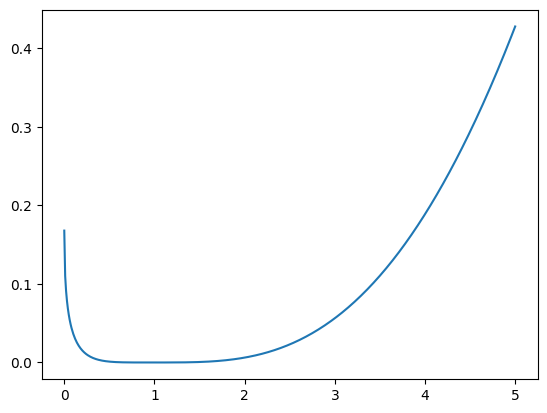

In [18]:
plt.plot(mu_scan, t_rate)
plt.show()

# Evaluating the likelihood (ratio): shape term

Here comes the NSBI!

## 1. Open the "mystery" dataset

This dataset has been generated according to a specific $\mu$ value

In [7]:
features = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy', 'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy', 'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy', 'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']
events = mcfm.from_csv(file_path = '/ptmp/mpp/taepa/higgs-offshell-interpretation/data/zz4l/ggZZ_sbi/analyzed.csv', kinematics = features, n_rows = 1e5)

w_asimov, _ = sigstr.scale(events, signal_strength = mu_asimov)

In [8]:
run_dir = 'run/h4l'
_, _, scaler_sbi_over_bkg, model_sbi_over_bkg = carl.utils.load_results(run_dir, 'sbi_over_bkg')
_, _, scaler_sig_over_bkg, model_sig_over_bkg = carl.utils.load_results(run_dir, 'sig_over_bkg')

In [9]:
r_sig_over_bkg_sm = carl.utils.get_likelihood_ratio(events, features, scaler_sig_over_bkg, model_sig_over_bkg)
r_sbi_over_bkg_sm = carl.utils.get_likelihood_ratio(events, features, scaler_sbi_over_bkg, model_sbi_over_bkg)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/afs/ipp-garching.mpg.de/home/t/taepa/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: ModelCheckpoint
You are using a CUDA devic

In [10]:
with open('data/xsec.json', 'r') as f:
    xs = json.load(f)
    xs_sig = np.prod(xs['sig'])
    xs_bkg = np.prod(xs['bkg'])
    xs_int = np.prod(xs['int'])
    xs_sbi = np.prod(xs['sbi'])

$$
\frac{p_{\rm sbi} (x | \mu)}{p_{\rm bkg} (x)} = \frac{\sigma_{\rm sig} (\mu - \sqrt{\mu}) r_{\rm sig} +\sigma_{\rm sbi} \sqrt{\mu} r_{\rm sbi} + \sigma_{\rm bkg}(1-\sqrt{\mu}) }{ \mu \sigma_{\rm sig} + \sqrt{\mu} \sigma_{\rm int} + \sigma_{\rm bkg} }
$$

In [11]:
multiplier_sig = mu_scan - torch.sqrt(mu_scan)
multiplier_sbi = torch.sqrt(mu_scan)
multiplier_bkg = 1 - torch.sqrt(mu_scan)

r_sbi_over_bkg_mu = ( xs_sig * multiplier_sig[None,:] * r_sig_over_bkg_sm[:,None] + xs_sbi * multiplier_sbi[None,:] * r_sbi_over_bkg_sm[:,None] + xs_bkg * multiplier_bkg[None,:] ) / (xs_sig * mu_scan + xs_int * torch.sqrt(mu_scan) + xs_bkg)

In [12]:
t_shape = -2 * torch.sum(lhc_lumi * torch.tensor(w_asimov)[:,None] * torch.log(r_sbi_over_bkg_mu), dim=0)

/tmp/ipykernel_1056525/3229738375.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_shape = -2 * torch.sum(lhc_lumi * torch.tensor(w_asimov)[:,None] * torch.log(r_sbi_over_bkg_mu), dim=0)


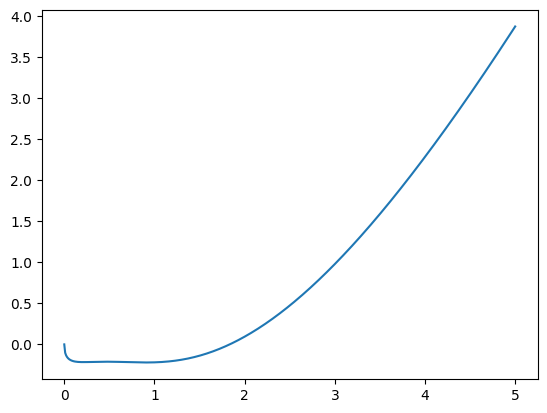

tensor(-0.2202, dtype=torch.float64)
tensor(0.9000)


In [13]:
plt.plot(mu_scan, t_shape)
plt.show()
print(torch.min(t_shape))
print(mu_scan[torch.argmin(t_shape)])

# Evaluating the likelihood (ratio): rate + shape

$$ t = t_{\rm rate} + t_{\rm shape} $$

In [14]:
t = t_rate + t_shape

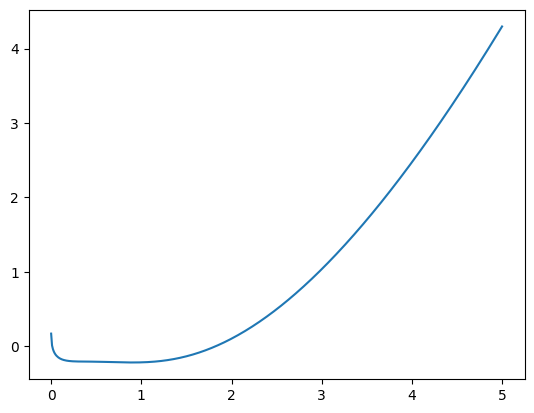

tensor(-0.2202, dtype=torch.float64)
tensor(0.9000)


In [15]:
plt.plot(mu_scan, t)
plt.show()
print(torch.min(t_shape))
print(mu_scan[torch.argmin(t_shape)])